# EBSD Multifractal Spectrum Sanity Check
*Validate the theorem $D_\alpha(h) = D_g(h+1)$ empirically by overlaying
spectra from three independent analysis pipelines on the same data.*

Each pipeline computes a $\sigma_{\max}$ scalar at each wavelet scale, runs
WTMM chains on it, and extracts $D(h)$ from the chain partition function.
Under the theorem, after appropriate h-axis shifts the three curves should
coincide within chain-sampling noise.

| Pipeline | Primary field | Jacobian source | Reported h frame |
|---|---|---|---|
| **main** | g (rotation, 3 comps) | CWT `derivs=first` → 3×2 κ | $h_g$ |
| **pantleon-Hessian** | α (Nye, 6 comps) | CWT `derivs=all` → 6×2 ∇α | $h_g$ (same as main) |
| **pantleon-gradient** | α (Nye, 6 comps) | np.gradient of α_cwt → 6×2 ∇α | $h_\alpha = h_g - 1$ |

**Expected**: D_main(h) ≈ D_hessian(h) ≈ D_gradient(h + 1), all plotted in a
common g-frame. Overlay plot makes this visible at a glance.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from numpy.fft import fftfreq
import ipywidgets as widgets
from IPython.display import display
import sys

import mlx.core as mx

sys.path.insert(0, 'XSmurfWrapper')
import xsmurf_wrapper as xsm

print(f"MLX: {mx.__version__}, xsmurf: {xsm.__version__}")
# --- Shear-zone additions ---
try:
    from orix.quaternion import Orientation, Rotation
    from orix.quaternion.symmetry import D2, D3, C1
    _HAS_ORIX = True
    print(f'orix available for rotation + symmetry ops')
except ImportError:
    _HAS_ORIX = False
    print('orix not in this env — rotation + KAM fall back to pure-numpy path')

JOSEPHINE_ROTATION_XLSX = Path('EBSD/Josephine_Peridotite_Olivine/1365-3_RotationMetadata.xlsx')
EBSD_DIR = Path('/Users/amasaryk/projects/Creep/wavelet/EBSD')


MLX: 0.31.1, xsmurf: 0.1.0
orix available for rotation + symmetry ops


In [3]:
def compute_scales(n_oct, n_vox, a_min=1):
    norm = 6.0 / 0.86
    return [a_min * (2.0 ** (o + v / n_vox)) * norm
            for o in range(n_oct) for v in range(n_vox)]

def _build_wavelet_filters_f32(kx, ky, scale, wavelet='gaussian'):
    sx = kx * scale
    sy = ky * scale
    gauss = mx.exp(-(sx * sx + sy * sy))
    zero = mx.zeros_like(gauss)
    def to_complex(r, i):
        return mx.stack([r, i], axis=-1).view(mx.complex64).squeeze(-1)
    if wavelet == 'mexican':
        k2 = sx * sx + sy * sy
        return {
            'dx':  to_complex(zero, sx * k2 * gauss),
            'dy':  to_complex(zero, sy * k2 * gauss),
            'dxx':  to_complex(-sx * sx * k2 * gauss, zero),
            'dxy':  to_complex(-sy * sx * k2 * gauss, zero),
            'dyy':  to_complex(-sy * sy * k2 * gauss, zero),
            'dxxx': to_complex(zero, -sx * sx * sx * k2 * gauss),
            'dxxy': to_complex(zero, -sx * sx * sy * k2 * gauss),
            'dxyy': to_complex(zero, -sx * sy * sy * k2 * gauss),
            'dyyy': to_complex(zero, -sy * sy * sy * k2 * gauss),
        }
    else:
        return {
            'dx':  to_complex(zero, sx * gauss),
            'dy':  to_complex(zero, sy * gauss),
            'dxx':  to_complex(-sx * sx * gauss, zero),
            'dxy':  to_complex(-sy * sx * gauss, zero),
            'dyy':  to_complex(-sy * sy * gauss, zero),
            'dxxx': to_complex(zero, -sx * sx * sx * gauss),
            'dxxy': to_complex(zero, -sx * sx * sy * gauss),
            'dxyy': to_complex(zero, -sx * sy * sy * gauss),
            'dyyy': to_complex(zero, -sy * sy * sy * gauss),
        }

def cwt_2d_f32(image, scales, pad=32, derivs='first', wavelet='gaussian', verbose=True):
    """2D CWT via MLX FFT. derivs='first' for dx,dy only; 'all' for up to 3rd order."""
    ny, nx = image.shape
    padded = np.pad(image, pad, mode='reflect').astype(np.float32)
    ny_p, nx_p = padded.shape
    crop = (slice(pad, pad + ny), slice(pad, pad + nx))
    kx_np = fftfreq(nx_p).astype(np.float32)
    ky_np = fftfreq(ny_p).astype(np.float32)
    KX_np, KY_np = np.meshgrid(kx_np, ky_np)
    KX, KY = mx.array(KX_np), mx.array(KY_np)
    image_fft = mx.fft.fft2(mx.array(padded))
    if derivs == 'first':
        names = ['dx', 'dy']
    else:
        names = ['dx', 'dy', 'dxx', 'dxy', 'dyy', 'dxxx', 'dxxy', 'dxyy', 'dyyy']
    n_scales = len(scales)
    result = {n: np.zeros((n_scales, ny, nx), dtype=np.float32) for n in names}
    result['mod'] = np.zeros((n_scales, ny, nx), dtype=np.float32)
    result['arg'] = np.zeros((n_scales, ny, nx), dtype=np.float32)
    for i, scale in enumerate(scales):
        filters = _build_wavelet_filters_f32(KX, KY, scale, wavelet=wavelet)
        for name in names:
            conv = mx.fft.ifft2(image_fft * filters[name])
            result[name][i] = np.array(conv.real)[crop]
        dx_s, dy_s = result['dx'][i], result['dy'][i]
        result['mod'][i] = np.sqrt(dx_s * dx_s + dy_s * dy_s)
        result['arg'][i] = np.arctan2(dy_s, dx_s).astype(np.float32)
        if verbose and (i % max(1, n_scales // 4) == 0 or i == n_scales - 1):
            print(f'  Scale {i}/{n_scales-1}: a={scale:.1f}')
    mx.eval()
    return result

def tensor_svd_3x2(gx1, gy1, gx2, gy2, gx3, gy3):
    """SVD of 3x2 Jacobian at every pixel via closed-form J^T J eigenvalues."""
    a = gx1*gx1 + gx2*gx2 + gx3*gx3
    b = gx1*gy1 + gx2*gy2 + gx3*gy3
    d = gy1*gy1 + gy2*gy2 + gy3*gy3
    trace = a + d
    det = a * d - b * b
    disc = np.sqrt(np.maximum((trace / np.float32(2))**2 - det, np.float32(0)))
    lambda1 = trace / np.float32(2) + disc
    lambda2 = np.maximum(trace / np.float32(2) - disc, np.float32(0))
    sigma_max = np.sqrt(np.maximum(lambda1, np.float32(0))).astype(np.float32)
    sigma_min = np.sqrt(lambda2).astype(np.float32)
    vx = lambda1 - d
    vy = b
    vnorm = np.sqrt(vx**2 + vy**2) + np.float32(1e-30)
    arg = np.arctan2(vy / vnorm, vx / vnorm).astype(np.float32)
    return sigma_max, sigma_min, arg

from xsmurf_wrapper.wavelet import gkapa_numpy, gkapap_numpy


print('CWT (first + all derivs) + tensor SVD + kapa/kapap functions defined')


CWT (first + all derivs) + tensor SVD + kapa/kapap functions defined


In [4]:
%matplotlib widget


In [5]:
def read_ctf(filepath):
    """Read an Oxford Instruments .ctf (Channel Text File) EBSD dataset.
    
    Returns
    -------
    data : dict with 2D arrays for each field + metadata dict
    """
    filepath = Path(filepath)
    with open(filepath, 'r', errors='replace') as f:
        lines = f.readlines()

    meta = {'filepath': str(filepath), 'name': filepath.stem}
    phases = {}
    header_line = None

    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped.startswith('XCells'):
            meta['xcells'] = int(stripped.split('\t')[1])
        elif stripped.startswith('YCells'):
            meta['ycells'] = int(stripped.split('\t')[1])
        elif stripped.startswith('XStep'):
            meta['xstep'] = float(stripped.split('\t')[1])
        elif stripped.startswith('YStep'):
            meta['ystep'] = float(stripped.split('\t')[1])
        elif stripped.startswith('Phases'):
            n_phases = int(stripped.split('\t')[1])
            for j in range(1, n_phases + 1):
                phases[j] = lines[i + j].strip().split('\t')
            meta['phases'] = phases
            meta['n_phases'] = n_phases
        elif stripped.startswith('Phase\tX\tY'):
            header_line = i
            break

    if header_line is None:
        raise ValueError(f"Could not find data header in {filepath}")

    # Read tabular data
    df = pd.read_csv(filepath, sep='\t', skiprows=header_line, engine='python',
                     on_bad_lines='skip')
    
    nx, ny = meta['xcells'], meta['ycells']
    expected = nx * ny
    actual = len(df)
    if actual != expected:
        print(f"  Warning: expected {expected} rows ({nx}x{ny}), got {actual}")
        # Truncate or pad
        if actual > expected:
            df = df.iloc[:expected]
        else:
            nx_adj = actual // ny if ny > 0 else nx
            meta['xcells'] = nx_adj
            nx = nx_adj

    data = {'meta': meta}
    shape = (ny, nx)
    for col in df.columns:
        try:
            data[col] = df[col].values.reshape(shape)
        except ValueError:
            data[col] = df[col].values  # keep flat if reshape fails

    # Convenience aliases
    data['euler1'] = data.get('Euler1', None)
    data['euler2'] = data.get('Euler2', None)
    data['euler3'] = data.get('Euler3', None)
    data['bc'] = data.get('BC', None)
    data['bs'] = data.get('BS', None)
    data['mad'] = data.get('MAD', None)
    data['phase'] = data.get('Phase', None)

    print(f"  Loaded {filepath.name}: {nx} x {ny}, step={meta.get('xstep','?')} µm, "
          f"{meta.get('n_phases','?')} phases")
    return data
# --- Oxford Instruments Channel 5 .cpr/.crc binary reader ---
# Pure-numpy reader for .cpr (ASCII INI metadata) + .crc (binary data) pairs.
# Field code mapping taken from defdap.file_readers.OxfordBinaryLoader source.
# Unlike defdap's loader, this one does NOT construct a crystal Phase object
# so it works for any Laue group (including trigonal quartz, monoclinic
# feldspars, etc.) that the narrow defdap Phase class would reject.

import re as _re_cpr

_CPR_FIELD_LOOKUP = {
    3:  ('ph1',      'float32'),   # Euler1 phi1 (rad)
    4:  ('phi',      'float32'),   # Euler2 Phi  (rad)
    5:  ('ph2',      'float32'),   # Euler3 phi2 (rad)
    6:  ('MAD',      'float32'),   # mean angular deviation
    7:  ('BC',       'uint8'),     # band contrast
    8:  ('BS',       'uint8'),     # band slope
    10: ('numBands', 'uint8'),
    11: ('AFI',      'uint8'),
    12: ('IB6',      'float32'),
}


def _parse_cpr_ini(cpr_path):
    text = Path(cpr_path).read_text(errors='replace')
    groups = {}
    current = None
    group_re = _re_cpr.compile(r'^\[(.+)\]\s*$')
    for line in text.splitlines():
        line = line.strip()
        if not line or line.startswith(';'):
            continue
        m = group_re.match(line)
        if m:
            current = m.group(1)
            groups.setdefault(current, {})
            continue
        if current is None:
            continue
        if '=' in line:
            k, v = line.split('=', 1)
            groups[current][k.strip()] = v.strip()
    return groups


def read_cpr(filepath):
    """Read an Oxford Instruments .cpr/.crc file pair.

    Returns the same dict shape as read_ctf():
        meta          dict with xcells, ycells, xstep, ystep, phases, n_phases, name
        euler1/2/3    (ny, nx) float32 arrays in DEGREES
        phase         (ny, nx) uint8 array
        bc, bs, mad   (ny, nx) arrays if present
        Plus any EDX windows as EDX_<element> keys.
    """
    filepath = Path(filepath)
    cpr_path = filepath.with_suffix('.cpr')
    crc_path = filepath.with_suffix('.crc')
    if not cpr_path.exists():
        raise FileNotFoundError(f"CPR header not found: {cpr_path}")
    if not crc_path.exists():
        raise FileNotFoundError(f"CRC binary not found: {crc_path}")

    groups = _parse_cpr_ini(cpr_path)

    # Grid & step
    job = groups.get('Job', {})
    nx = int(job['xCells'])
    ny = int(job['yCells'])
    xstep = float(job.get('GridDistX', 1.0))
    ystep = float(job.get('GridDistY', xstep))

    # Phases: assemble ctf-like metadata so downstream cells keep working
    pg = groups.get('Phases', {})
    n_phases = int(pg.get('Count', 0))
    phases = {}
    for i in range(1, n_phases + 1):
        pi = groups.get(f'Phase{i}', {})
        lattice = '{};{};{}'.format(pi.get('a', '?'), pi.get('b', '?'), pi.get('c', '?'))
        angles = '{};{};{}'.format(pi.get('alpha', '?'), pi.get('beta', '?'), pi.get('gamma', '?'))
        phases[i] = [lattice, angles,
                     pi.get('StructureName', f'phase_{i}'),
                     pi.get('LaueGroup', '?'), pi.get('SpaceGroup', '?')]

    # EDX window names (field codes 100+i)
    edx_names = {}
    edx_group = groups.get('EDX Windows', {})
    if edx_group:
        n_edx = int(edx_group.get('Count', 0))
        for i in range(1, n_edx + 1):
            key = edx_group.get(f'Window{i}', f'edx{i}')
            edx_names[100 + i] = key

    # Build the binary record dtype from the [Fields] section
    fg = groups.get('Fields', {})
    n_fields = int(fg.get('Count', 0))
    dtype_items = [('phase', 'uint8')]   # phase is always first, uint8
    unknown = 0
    for i in range(1, n_fields + 1):
        code = int(fg[f'Field{i}'])
        if code in _CPR_FIELD_LOOKUP:
            dtype_items.append(_CPR_FIELD_LOOKUP[code])
        elif code in edx_names:
            dtype_items.append((f'EDX_{edx_names[code]}', 'float32'))
        else:
            unknown += 1
            dtype_items.append((f'unknown_{unknown}_code{code}', 'float32'))
            print(f'  warning: unknown CPR field code {code}, guessing float32')
    record_dtype = np.dtype(dtype_items)

    # Load binary
    raw = np.fromfile(str(crc_path), dtype=record_dtype, count=nx * ny)
    if raw.size != nx * ny:
        raw = raw[:nx * ny]
        print(f'  warning: CRC short read ({raw.size} records)')

    shape = (ny, nx)
    data = {'meta': {
        'filepath': str(filepath),
        'name': filepath.stem,
        'xcells': nx, 'ycells': ny,
        'xstep': xstep, 'ystep': ystep,
        'phases': phases, 'n_phases': n_phases,
        'format': 'cpr',
    }}

    data['phase'] = raw['phase'].reshape(shape)

    # CPR stores Euler in radians; convert to degrees to match ctf convention
    for raw_key, deg_key in [('ph1', 'euler1'), ('phi', 'euler2'), ('ph2', 'euler3')]:
        if raw_key in raw.dtype.names:
            data[deg_key] = np.rad2deg(raw[raw_key].reshape(shape)).astype(np.float32)

    if 'MAD' in raw.dtype.names: data['mad'] = raw['MAD'].reshape(shape)
    if 'BC'  in raw.dtype.names: data['bc']  = raw['BC'].reshape(shape)
    if 'BS'  in raw.dtype.names: data['bs']  = raw['BS'].reshape(shape)
    if 'numBands' in raw.dtype.names: data['bands'] = raw['numBands'].reshape(shape)
    for name in raw.dtype.names:
        if name.startswith('EDX_'):
            data[name] = raw[name].reshape(shape)

    print(f'  CPR: {nx}x{ny} @ {xstep} um, {n_phases} phases, {len(dtype_items)} fields')
    return data


def read_ebsd(filepath):
    """Dispatch to the right EBSD reader based on file extension."""
    filepath = Path(filepath)
    ext = filepath.suffix.lower()
    if ext == '.ctf':
        return read_ctf(filepath)
    elif ext in ('.cpr', '.crc'):
        return read_cpr(filepath)
    else:
        raise ValueError(f"Unsupported EBSD extension: {ext} (expected .ctf or .cpr/.crc)")


In [6]:
EBSD_DIR = Path('EBSD')

# --- Loadable files: .ctf (ASCII) and .cpr (Oxford binary via read_cpr) ---
ctf_files = sorted(EBSD_DIR.rglob('*.ctf'))
cpr_files = sorted(EBSD_DIR.rglob('*.cpr'))
ebsd_files = sorted(ctf_files + cpr_files, key=lambda p: (p.parts[:-1], p.name))

# Shear-zone folder tags
SHEAR_ZONE_TAGS = {
    'Calamita_Elba_Quartzite':           ('[CAL]', 'Calamita quartzite'),
    'Kuckaus_Namibia_Feldspar_Mylonite': ('[KUC]', 'Kuckaus polymineralic mylonite'),
    'Josephine_Peridotite_Olivine':      ('[JOS]', 'Josephine peridotite'),
}

def _tag(path):
    rel = path.relative_to(EBSD_DIR)
    root = rel.parts[0] if rel.parts else ''
    return SHEAR_ZONE_TAGS.get(root, ('[...]', root))[0]

labels = []
for p in ebsd_files:
    rel = p.relative_to(EBSD_DIR)
    labels.append(f'{_tag(p)} {rel}  [{p.suffix[1:]}]')

print(f'Found {len(ebsd_files)} EBSD files ({len(ctf_files)} CTF + {len(cpr_files)} CPR):\n')
from collections import defaultdict
by_tag = defaultdict(list)
for i, p in enumerate(ebsd_files):
    by_tag[_tag(p)].append(i)
for tag, idxs in by_tag.items():
    print(f'  {tag}  ({len(idxs)} files)')
    for i in idxs:
        rel = ebsd_files[i].relative_to(EBSD_DIR)
        print(f'    [{i:3d}] {rel}  [{ebsd_files[i].suffix[1:]}]')
    print()


Found 61 EBSD files (54 CTF + 7 CPR):

  [...]  (24 files)
    [  0] 2013-05-16_Pearce_Mark_6535v1/data/Overview_Map_Processed.ctf  [ctf]
    [  1] 2013-05-16_Pearce_Mark_6535v1/data/Overview_Map_Raw.ctf  [ctf]
    [  2] 2013-05-16_Pearce_Mark_6535v1/data/Siderite_Detail_Processed.ctf  [ctf]
    [  3] 2013-05-16_Pearce_Mark_6535v1/data/Siderite_Detail_Raw.ctf  [ctf]
    [  4] 2015-06-19_Pearce_Mark_13960v1/data/Large_Albite.ctf  [ctf]
    [  5] 2015-06-19_Pearce_Mark_13960v1/data/Large_Albite_processed.ctf  [ctf]
    [  6] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_Original.ctf  [ctf]
    [  7] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4ci.ctf  [ctf]
    [  8] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4cii.ctf  [ctf]
    [  9] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4ciii.ctf  [ctf]
    [ 10] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4di.ctf  [ctf]
    [ 11] 2015-06-26_Pearce_Mark_13963v1/data/Twinn

In [7]:
# ---- Pick a dataset by index ----
DATASET_IDX = 20# <-- change this to select a different file

ebsd_path = ebsd_files[DATASET_IDX]
ctf_path = ebsd_path                        # alias: downstream cells look at ctf_path
print(f'Selected: {labels[DATASET_IDX]}')
print(f'  Path: {ebsd_path}')

ebsd = read_ebsd(ebsd_path)
meta = ebsd['meta']


Selected: [CAL] Calamita_Elba_Quartzite/EBSD Map 1/SP78_Map_1.cpr  [cpr]
  Path: EBSD/Calamita_Elba_Quartzite/EBSD Map 1/SP78_Map_1.cpr
  CPR: 414x310 @ 2.4 um, 1 phases, 10 fields


Phases: {np.uint8(0): np.int64(16615), np.uint8(1): np.int64(111725)}
Dominant phase: 1
  Phase 1: Quartz-new, Laue=7 -> Symmetry (12,) 622
[[ 1.     0.     0.     0.   ]
 [ 0.5    0.     0.     0.866]
 [-0.5    0.     0.     0.866]
 [ 0.     0.     0.     1.   ]
 [-0.866  0.     0.     0.5  ]
 [-0.866  0.     0.    -0.5  ]
 [ 0.     1.     0.     0.   ]
 [ 0.     0.5    0.866  0.   ]
 [ 0.    -0.5    0.866  0.   ]
 [ 0.     0.     1.     0.   ]
 [ 0.    -0.866  0.5    0.   ]
 [ 0.    -0.866 -0.5    0.   ]]
Phase mask: 111725/128340 (87.1%)
Computing KAM (kernel=1)...
  Kernel=1 -> 3x3, 4 unique neighbor pairs
KAM: [0.0000, 88.6747] deg, median=0.9663


/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_8700/1500603122.py:91: RuntimeWarning: invalid value encountered in divide
  kam = np.where(count > 0, kam / count, 0)


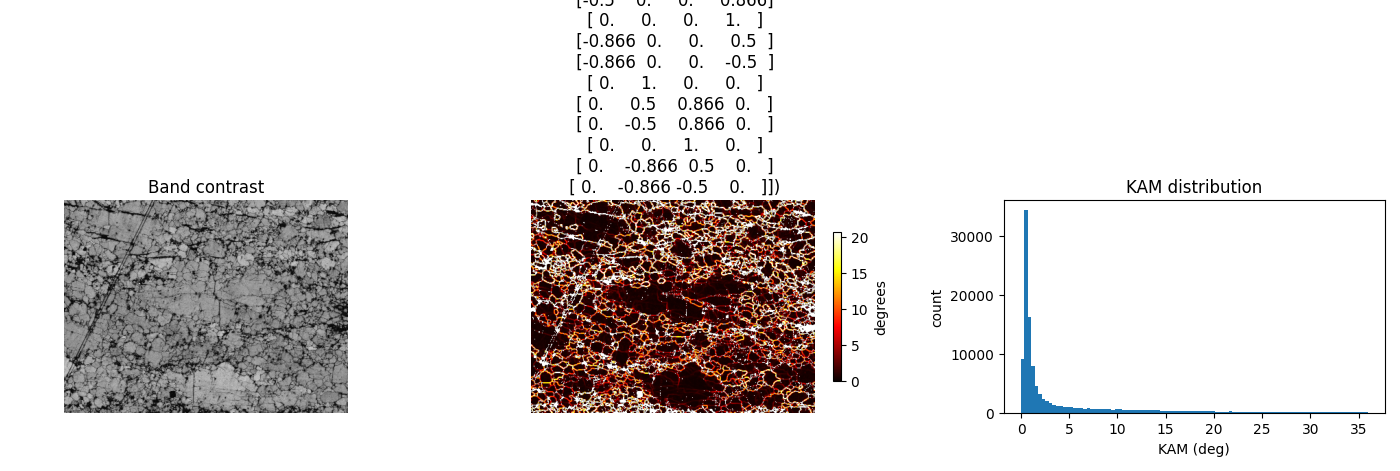

In [8]:
# ===== KAM via orix (symmetry-aware) =====

from orix.quaternion import Orientation
from orix.quaternion.symmetry import C1, C2, D2, D3, D6, C4, Oh

# ---------- USER PARAMETERS ----------
KAM_KERNEL = 1   # Kernel radius: 1 = 3x3, 2 = 5x5, 3 = 7x7, etc.
# --------------------------------------

LAUE_TO_ORIX = {
    '1': C1, '2': C2, '3': D2, '6': D3, '7': D6, '9': Oh, '11': C1,
}

def get_phase_symmetry(ebsd_data, phase_id=1):
    phases = ebsd_data['meta'].get('phases', {})
    if phase_id in phases:
        info = phases[phase_id]
        laue_str = str(info[3]).strip() if len(info) > 3 else '?'
        sym = LAUE_TO_ORIX.get(laue_str, None)
        name = info[2] if len(info) > 2 else f'phase_{phase_id}'
        print(f'  Phase {phase_id}: {name}, Laue={laue_str} -> {sym}')
        return sym
    return None


def compute_kam_orix(e1_deg, e2_deg, e3_deg, symmetry, mask=None,
                      kernel=1, degrees=True):
    """Compute KAM using orix Orientation.angle_with().

    kernel: neighborhood radius in pixels.
        1 = 3x3 (8 neighbors), 2 = 5x5 (24 neighbors), etc.
        Matches MTEX/OIM convention.
    """
    ny, nx = e1_deg.shape
    euler_rad = np.deg2rad(np.stack([e1_deg, e2_deg, e3_deg], axis=-1)).astype(np.float64)

    ori = Orientation.from_euler(euler_rad.reshape(-1, 3), symmetry=symmetry)
    ori = ori.reshape(ny, nx)

    kam = np.zeros((ny, nx), dtype=np.float64)
    count = np.zeros((ny, nx), dtype=np.float64)

    if mask is None:
        mask = np.ones((ny, nx), dtype=bool)

    # Generate all (dy, dx) offsets within the kernel radius
    offsets = []
    for dy in range(-kernel, kernel + 1):
        for dx in range(-kernel, kernel + 1):
            if dy == 0 and dx == 0:
                continue
            # Only count each pair once: (dy,dx) and (-dy,-dx) are the same pair
            if (dy, dx) > (0, 0) or (dy == 0 and dx > 0):
                offsets.append((dy, dx))

    print(f'  Kernel={kernel} -> {2*kernel+1}x{2*kernel+1}, {len(offsets)} unique neighbor pairs')

    for dy, dx in offsets:
        # Slice pairs so ori1[i,j] is compared with ori2[i,j] = ori1[i+dy, j+dx]
        if dy >= 0:
            sy1 = slice(None, ny - dy) if dy > 0 else slice(None)
            sy2 = slice(dy, None) if dy > 0 else slice(None)
        else:
            sy1 = slice(-dy, None)
            sy2 = slice(None, ny + dy)

        if dx >= 0:
            sx1 = slice(None, nx - dx) if dx > 0 else slice(None)
            sx2 = slice(dx, None) if dx > 0 else slice(None)
        else:
            sx1 = slice(-dx, None)
            sx2 = slice(None, nx + dx)

        o1 = ori[sy1, sx1]
        o2 = ori[sy2, sx2]
        m = mask[sy1, sx1] & mask[sy2, sx2]

        if not m.any():
            continue

        angles = np.full(o1.shape, np.nan)
        angles[m] = o1[m].angle_with(o2[m])
        v = np.isfinite(angles)
        a = np.where(v, angles, 0)

        kam[sy1, sx1] += a
        kam[sy2, sx2] += a
        count[sy1, sx1] += v
        count[sy2, sx2] += v

    kam = np.where(count > 0, kam / count, 0)
    kam[~mask] = np.nan
    if degrees:
        kam = np.rad2deg(kam)
    return kam


# --- Compute KAM for current dataset ---
phase_map = ebsd['phase']
unique_phases, phase_counts = np.unique(phase_map, return_counts=True)
dominant_phase = unique_phases[np.argmax(phase_counts)]
print(f'Phases: {dict(zip(unique_phases, phase_counts))}')
print(f'Dominant phase: {dominant_phase}')

sym = get_phase_symmetry(ebsd, phase_id=dominant_phase)
if sym is None:
    for pid in unique_phases:
        sym = get_phase_symmetry(ebsd, phase_id=int(pid))
        if sym is not None:
            dominant_phase = int(pid)
            break
if sym is None:
    print('WARNING: could not determine symmetry, using C1')
    sym = C1

phase_mask = (phase_map == dominant_phase)
print(f'Phase mask: {phase_mask.sum()}/{phase_mask.size} ({phase_mask.mean():.1%})')

print(f'Computing KAM (kernel={KAM_KERNEL})...')
kam = compute_kam_orix(ebsd['euler1'], ebsd['euler2'], ebsd['euler3'],
                        symmetry=sym, mask=phase_mask,
                        kernel=KAM_KERNEL, degrees=True)
print(f'KAM: [{np.nanmin(kam):.4f}, {np.nanmax(kam):.4f}] deg, median={np.nanmedian(kam):.4f}')

ny, nx = kam.shape
aspect = ny / nx
fig_w = 14
fig_h = max(4, fig_w * aspect * 0.45)

fig, axes = plt.subplots(1, 3, figsize=(fig_w, fig_h))
axes[0].imshow(ebsd['bc'], cmap='gray', aspect='equal')
axes[0].set_title('Band contrast')
im = axes[1].imshow(kam, cmap='hot', vmin=0, vmax=np.nanpercentile(kam, 95), aspect='equal')
axes[1].set_title(f'KAM (kernel={KAM_KERNEL}, {sym})')
plt.colorbar(im, ax=axes[1], label='degrees', shrink=0.7)
axes[2].hist(kam[np.isfinite(kam)].ravel(), bins=100,
             range=(0, np.nanpercentile(kam, 99)))
axes[2].set(xlabel='KAM (deg)', ylabel='count', title='KAM distribution')
for ax in axes[:2]: ax.axis('off')
plt.tight_layout()
plt.show()

In [9]:
# ===== Quaternion helpers (shared) =====
def _quat_mul(a, b):
    """Hamilton product.  Broadcasts over leading dims.  Last dim = 4 (w, x, y, z)."""
    aw, ax, ay, az = a[..., 0], a[..., 1], a[..., 2], a[..., 3]
    bw, bx, by, bz = b[..., 0], b[..., 1], b[..., 2], b[..., 3]
    return np.stack([
        
        aw * bw - ax * bx - ay * by - az * bz,
        aw * bx + ax * bw + ay * bz - az * by,
        aw * by - ax * bz + ay * bw + az * bx,
        aw * bz + ax * by - ay * bx + az * bw,
    ], axis=-1)

def _quat_conj(q):
    out = q.copy()
    out[..., 1:] *= -1.0
    return out


## Grain identification (adjacency flood-fill, no kernels)

In [10]:
# ===== Grain identification via symmetry-aware adjacency flood-fill =====
# No kernels / windows: pixel neighbors only.  scipy.ndimage.label on a
# "same grain" adjacency graph built from per-neighbor misorientation.

from scipy.ndimage import label as ndi_label

# ---- parameters ----
GRAIN_THETA_DEG   = 4.0  # high-angle GB threshold (deg); 2 deg for subgrains
GRAIN_MIN_PIXELS  = 10    # drop grains smaller than this (stats only)
# ---------------------

def _sym_miso_angle(q_a, q_b, sym_q):
    """Symmetry-reduced misorientation angle between two quaternion arrays.
    q_a, q_b: (N, 4) unit quaternions.  sym_q: (S, 4) symmetry ops.
    Returns (N,) angles in radians (smallest under the point group)."""
    q_rel = _quat_mul(_quat_conj(q_a), q_b)           # (N, 4)
    q_sym = _quat_mul(q_rel[:, None, :], sym_q[None, :, :])  # (N, S, 4)
    w = np.abs(q_sym[..., 0])                         # (N, S)
    w_max = np.clip(w.max(axis=1), -1.0, 1.0)
    return 2.0 * np.arccos(w_max)

def identify_grains(ebsd_data, theta_c_deg=GRAIN_THETA_DEG):
    """Symmetry-aware grain segmentation.
    Returns: grain_id (ny, nx) int32 (0 = unindexed/background, ≥1 = grain id).
    Algorithm:
      - for each phase, compute pixel-right and pixel-down misorientation (adjacency only)
      - threshold to build 'same grain' edge graph
      - connected-components label within phase
      - concatenate grain ids across phases with unique offsets
    """
    e1 = np.deg2rad(ebsd_data['euler1'].astype(np.float64))
    e2 = np.deg2rad(ebsd_data['euler2'].astype(np.float64))
    e3 = np.deg2rad(ebsd_data['euler3'].astype(np.float64))
    phase = ebsd_data['phase']
    ny, nx = e1.shape

    # Build unit quaternion map (from Euler via orix)
    ori_all = Orientation.from_euler(np.stack([e1.ravel(), e2.ravel(), e3.ravel()], axis=1))
    q = ori_all.data.reshape(ny, nx, 4).astype(np.float64)
    q *= np.where(q[..., 0:1] >= 0, 1.0, -1.0)

    theta_c = np.deg2rad(theta_c_deg)
    grain_id = np.zeros((ny, nx), dtype=np.int32)
    gid_offset = 0

    for pid in [int(p) for p in np.unique(phase) if int(p) > 0]:
        pmask = (phase == pid)
        if pmask.sum() < GRAIN_MIN_PIXELS:
            continue
        sym = get_phase_symmetry(ebsd_data, phase_id=pid)
        if sym is None:
            sym = C1
        sym_q = sym.data.astype(np.float64)

        # Right-neighbor misorientation: between (y, x) and (y, x+1)
        a = q[:, :-1, :].reshape(-1, 4)
        b = q[:,  1:, :].reshape(-1, 4)
        theta_right = _sym_miso_angle(a, b, sym_q).reshape(ny, nx - 1)

        # Down-neighbor misorientation: between (y, x) and (y+1, x)
        a = q[:-1, :, :].reshape(-1, 4)
        b = q[ 1:, :, :].reshape(-1, 4)
        theta_down = _sym_miso_angle(a, b, sym_q).reshape(ny - 1, nx)

        # Build same-phase adjacency: both pixels must be in this phase
        both_r = pmask[:, :-1] & pmask[:, 1:]
        both_d = pmask[:-1, :] & pmask[1:, :]

        # Same-grain edges
        same_r = both_r & (theta_right < theta_c)
        same_d = both_d & (theta_down  < theta_c)

        # Expand edge flags to a 4-connected adjacency-friendly mask:
        # a pixel is "connected to its right/down neighbor" iff same_r/same_d is True.
        # scipy.ndimage.label can use a custom structure on a binary image, but we
        # want connectivity conditional on edge labels.  Easiest: build a pseudo-pixel
        # structure by union-find over edges.
        # Use a lightweight Union-Find implementation.
        n_pix = ny * nx
        parent = np.arange(n_pix, dtype=np.int64)

        def find(i):
            while parent[i] != i:
                parent[i] = parent[parent[i]]
                i = parent[i]
            return i

        def union(i, j):
            ri, rj = find(i), find(j)
            if ri != rj:
                parent[rj] = ri

        ys, xs = np.where(same_r)
        for y, x in zip(ys, xs):
            union(y * nx + x, y * nx + (x + 1))

        ys, xs = np.where(same_d)
        for y, x in zip(ys, xs):
            union(y * nx + x, (y + 1) * nx + x)

        # Harvest roots → local labels
        roots = np.array([find(i) for i in range(n_pix)], dtype=np.int64)
        # Only keep labels inside phase mask
        ravel_mask = pmask.ravel()
        # Remap roots to 1..K
        uniq_roots, inv = np.unique(roots[ravel_mask], return_inverse=True)
        local_lbl = np.zeros(n_pix, dtype=np.int32)
        local_lbl[ravel_mask] = inv.astype(np.int32) + 1
        local_lbl = local_lbl.reshape(ny, nx)

        # Offset and assign
        n_this = int(local_lbl.max())
        lbl_off = np.where(local_lbl > 0, local_lbl + gid_offset, 0)
        grain_id[pmask] = lbl_off[pmask]
        gid_offset += n_this

    return grain_id


# ---- Run ----
grain_id = identify_grains(ebsd, theta_c_deg=GRAIN_THETA_DEG)
n_grains_total = int(grain_id.max())
sizes = np.bincount(grain_id.ravel())[1:]  # skip background
n_big = int((sizes >= GRAIN_MIN_PIXELS).sum())
print(f'Grains found: {n_grains_total} total, {n_big} with >= {GRAIN_MIN_PIXELS} px')
print(f'Median grain size: {int(np.median(sizes)) if len(sizes) else 0} px, '
      f'max: {int(sizes.max()) if len(sizes) else 0} px')


  Phase 1: Quartz-new, Laue=7 -> Symmetry (12,) 622
[[ 1.     0.     0.     0.   ]
 [ 0.5    0.     0.     0.866]
 [-0.5    0.     0.     0.866]
 [ 0.     0.     0.     1.   ]
 [-0.866  0.     0.     0.5  ]
 [-0.866  0.     0.    -0.5  ]
 [ 0.     1.     0.     0.   ]
 [ 0.     0.5    0.866  0.   ]
 [ 0.    -0.5    0.866  0.   ]
 [ 0.     0.     1.     0.   ]
 [ 0.    -0.866  0.5    0.   ]
 [ 0.    -0.866 -0.5    0.   ]]
Grains found: 6986 total, 1758 with >= 10 px
Median grain size: 2 px, max: 3580 px


## Per-grain demean + log orientation

In [11]:
# ===== Per-grain Karcher mean + demean + log orientation =====
# Per-grain symmetry-aware mean reference; log map reduces to FZ.

# ---- options ----
CAXIS_TO_Z = True     # rotate each grain reference so c-axis || sample Z (quartz only)
FZ_WARN_FRAC = 0.7    # warn when per-pixel disorientation exceeds this fraction of FZ max
# -----------------

# FZ max disorientation (deg) per point group (approximate, proper rotation group)
FZ_MAX_DEG_BY_NAME = {
    'D6h': 93.8, 'D6': 93.8, 'C6h': 93.8, 'C6': 93.8,
    'D4h': 98.4, 'D4': 98.4, 'C4h': 98.4, 'C4': 98.4,
    'D3d': 104.5, 'D3': 104.5, 'C3v': 104.5, 'C3': 120.0,
    'D2h': 120.7, 'D2': 120.7, 'C2h': 180.0, 'C2': 180.0,
    'Ci':  180.0, 'C1':  180.0,
    'Oh':  62.8, 'O':  62.8, 'Td': 62.8, 'Th': 62.8, 'T': 62.8,
    'S6':  180.0, 'S4': 180.0, 'Cs':  180.0,
}

def _karcher_mean_grain(q_grain, sym_q, max_iter=5, tol=1e-4):
    """Symmetry-aware Karcher mean of unit quaternions within a grain."""
    n = len(q_grain)
    q_grain = q_grain * np.where(q_grain[:, 0:1] >= 0, 1.0, -1.0)
    # Seed = orientation tensor dominant eigenvector
    T = (q_grain.T @ q_grain) / n
    _, eigvecs = np.linalg.eigh(T)
    q_ref = eigvecs[:, -1]
    if q_ref[0] < 0:
        q_ref = -q_ref
    for _ in range(max_iter):
        # Choose symmetry-equivalent closest to q_ref for each pixel
        q_sym = _quat_mul(q_grain[:, None, :], sym_q[None, :, :])  # (N, S, 4)
        rel = _quat_mul(_quat_conj(q_ref)[None, None, :], q_sym)
        rel *= np.where(rel[..., 0:1] >= 0, 1.0, -1.0)
        best = np.argmax(rel[..., 0], axis=1)
        q_aligned = q_sym[np.arange(n), best]
        q_aligned *= np.where(q_aligned[:, 0:1] >= 0, 1.0, -1.0)
        T = (q_aligned.T @ q_aligned) / n
        _, eigvecs = np.linalg.eigh(T)
        q_new = eigvecs[:, -1]
        if q_new[0] < 0:
            q_new = -q_new
        if abs(float(q_ref @ q_new)) > 1.0 - tol:
            break
        q_ref = q_new
    return q_ref, q_aligned

def _rotation_to_align_caxis_with_z(q_ref):
    """Return quaternion r such that (r * q_ref) places crystal c-axis along sample Z.
    Crystal c-axis in crystal frame = (0, 0, 1).  Rotate crystal frame by q_ref
    into sample frame; we then want r so that r composed with the rotated c-axis
    points along sample Z.  Implementation: compute rotated c-axis, then rigid
    rotation bringing that vector to (0, 0, 1)."""
    # Rotate (0, 0, 1) by q_ref: v = q_ref * (0,0,0,1) * q_ref^-1
    w, x, y, z = q_ref
    # Quaternion rotation of unit z-axis:
    vx = 2.0 * (x * z + w * y)
    vy = 2.0 * (y * z - w * x)
    vz = 1.0 - 2.0 * (x * x + y * y)
    v = np.array([vx, vy, vz])
    v /= np.linalg.norm(v) + 1e-12
    z_axis = np.array([0.0, 0.0, 1.0])
    cosang = float(np.clip(v @ z_axis, -1.0, 1.0))
    if cosang > 1.0 - 1e-9:
        return np.array([1.0, 0.0, 0.0, 0.0])
    if cosang < -1.0 + 1e-9:
        return np.array([0.0, 1.0, 0.0, 0.0])  # 180 deg about x
    axis = np.cross(v, z_axis)
    axis /= np.linalg.norm(axis) + 1e-12
    ang = np.arccos(cosang)
    s = np.sin(ang / 2.0)
    return np.array([np.cos(ang / 2.0), axis[0] * s, axis[1] * s, axis[2] * s])

def compute_log_orientation_per_grain(ebsd_data, grain_id, caxis_to_z=CAXIS_TO_Z):
    """Per-grain demean + log map.
    Returns dict: grain_id -> {q_ref, q_align_rot, log_field_slice, mask, phase_id,
                                theta_p99_deg, fz_max_deg, fz_warn}
    Also returns a combined (ny, nx, 3) log field with per-grain demeaned values.
    """
    e1 = np.deg2rad(ebsd_data['euler1'].astype(np.float64))
    e2 = np.deg2rad(ebsd_data['euler2'].astype(np.float64))
    e3 = np.deg2rad(ebsd_data['euler3'].astype(np.float64))
    phase = ebsd_data['phase']
    ny, nx = e1.shape

    ori_all = Orientation.from_euler(np.stack([e1.ravel(), e2.ravel(), e3.ravel()], axis=1))
    q_map = ori_all.data.reshape(ny, nx, 4).astype(np.float64)
    q_map *= np.where(q_map[..., 0:1] >= 0, 1.0, -1.0)

    combined_log = np.zeros((ny, nx, 3), dtype=np.float32)
    combined_mask = np.zeros((ny, nx), dtype=bool)
    grain_info = {}

    gids = [int(g) for g in np.unique(grain_id) if int(g) > 0]
    print(f'Processing {len(gids)} grains...')

    for gi, gid in enumerate(gids):
        gmask = (grain_id == gid)
        n_pix = int(gmask.sum())
        if n_pix < GRAIN_MIN_PIXELS:
            continue
        ys, xs = np.where(gmask)
        pid = int(phase[ys[0], xs[0]])
        sym = get_phase_symmetry(ebsd_data, phase_id=pid)
        if sym is None:
            sym = C1
        sym_q = sym.data.astype(np.float64)

        q_grain = q_map[ys, xs, :]            # (n, 4)
        q_ref, q_aligned = _karcher_mean_grain(q_grain, sym_q)

        # Optional rigid rotation bringing c-axis || Z
        if caxis_to_z:
            r = _rotation_to_align_caxis_with_z(q_ref)
            # Apply r to q_ref and to aligned pixels: q' = r * q
            q_ref_new  = _quat_mul(r[None, :], q_ref[None, :])[0]
            q_aligned_new = _quat_mul(r[None, :], q_aligned)
        else:
            r = np.array([1.0, 0.0, 0.0, 0.0])
            q_ref_new = q_ref
            q_aligned_new = q_aligned

        # Disorientation: q_rel = q_ref^-1 * q_aligned  (already picked symmetry rep)
        rel = _quat_mul(_quat_conj(q_ref_new)[None, :], q_aligned_new)
        rel *= np.where(rel[:, 0:1] >= 0, 1.0, -1.0)
        w = np.clip(rel[:, 0], -1.0, 1.0)
        theta = 2.0 * np.arccos(w)
        sin_half = np.sqrt(np.maximum(1.0 - w * w, 0.0))
        small = sin_half < 1e-8
        safe = np.where(small, 1.0, sin_half)
        axis = rel[:, 1:4] / safe[:, None]
        axis[small] = 0.0
        omega = theta[:, None] * axis
        omega[small] = 2.0 * rel[small, 1:4]

        combined_log[ys, xs, :] = omega.astype(np.float32)
        combined_mask[ys, xs]   = True

        # FZ validity check
        sym_name = sym.__class__.__name__ if sym is not None else 'C1'
        fz_max = FZ_MAX_DEG_BY_NAME.get(sym_name, 180.0)
        p99 = float(np.rad2deg(np.percentile(theta, 99))) if n_pix else 0.0
        fz_warn = bool(p99 > FZ_WARN_FRAC * fz_max)

        grain_info[gid] = {
            'phase_id': pid,
            'n_pixels': n_pix,
            'q_ref': q_ref_new,
            'rot_to_z': r,
            'theta_p99_deg': p99,
            'fz_max_deg': fz_max,
            'fz_warn': fz_warn,
            'sym_name': sym_name,
        }

    n_warn = sum(1 for g in grain_info.values() if g['fz_warn'])
    if n_warn:
        print(f'  WARNING: {n_warn} grain(s) near FZ boundary (log chart may be unreliable).')
        print('  Consider splitting via subgrain segmentation (theta_c = 2 deg).')

    return combined_log, combined_mask, grain_info


combined_log, combined_mask, grain_info = compute_log_orientation_per_grain(
    ebsd, grain_id, caxis_to_z=CAXIS_TO_Z)
print(f'Combined per-grain log field: {combined_mask.sum()}/{combined_mask.size} pixels')
print(f'log_field  abs median: {np.median(np.abs(combined_log[combined_mask])):.4f}')
print(f'log_field  abs p99:    {np.percentile(np.abs(combined_log[combined_mask]), 99):.4f}')


Processing 6986 grains...
  Phase 1: Quartz-new, Laue=7 -> Symmetry (12,) 622
[[ 1.     0.     0.     0.   ]
 [ 0.5    0.     0.     0.866]
 [-0.5    0.     0.     0.866]
 [ 0.     0.     0.     1.   ]
 [-0.866  0.     0.     0.5  ]
 [-0.866  0.     0.    -0.5  ]
 [ 0.     1.     0.     0.   ]
 [ 0.     0.5    0.866  0.   ]
 [ 0.    -0.5    0.866  0.   ]
 [ 0.     0.     1.     0.   ]
 [ 0.    -0.866  0.5    0.   ]
 [ 0.    -0.866 -0.5    0.   ]]
  Phase 1: Quartz-new, Laue=7 -> Symmetry (12,) 622
[[ 1.     0.     0.     0.   ]
 [ 0.5    0.     0.     0.866]
 [-0.5    0.     0.     0.866]
 [ 0.     0.     0.     1.   ]
 [-0.866  0.     0.     0.5  ]
 [-0.866  0.     0.    -0.5  ]
 [ 0.     1.     0.     0.   ]
 [ 0.     0.5    0.866  0.   ]
 [ 0.    -0.5    0.866  0.   ]
 [ 0.     0.     1.     0.   ]
 [ 0.    -0.866  0.5    0.   ]
 [ 0.    -0.866 -0.5    0.   ]]
  Phase 1: Quartz-new, Laue=7 -> Symmetry (12,) 622
[[ 1.     0.     0.     0.   ]
 [ 0.5    0.     0.     0.866]
 [-0.5    

## Sanity Check: Three Pipelines on One Dataset


### S-1. Compute $\sigma_{\max}$ from three Jacobian constructions


In [12]:
# ===== Compute sigma_max at each scale from three Jacobian sources =====
# (1) main      : 3x2 kappa SVD (first-deriv wavelet on g, wavelet=mexican)
# (2) pantleon  : 6x2 alpha-Jacobian SVD via wavelet Hessian (derivs=all, gaussian)
# (3) gradient  : 6x2 alpha-Jacobian SVD via np.gradient on alpha_cwt

from xsmurf_wrapper.anchor_chain import chain_and_extract
import xsmurf_wrapper as xsm

# ---- parameters (intentionally coarse / fast) ----
FRACINT_ALPHA = .5
PAD           = 32
THRESH        = 1e-6
A_MIN         = 1.863
N_OCT         = 4
N_VOX         = 20        # coarser than production (20) -- 24 scales instead of 80
SIMILITUDE    = 0.8
BORDER_PCT    = 1.0
DIST_FRAC     = 0.9
SMOOTH_CHAIN  = True
CHAIN_METHOD  = 'greedy'

# --- Frame unification: absorbs the +1 alpha-vs-g Hölder shift into the
# fractional-integration factor for grad & fdfirst pipelines so ALL five
# pipelines report in the g-frame after the same downstream eta subtraction.
# Equivalent to applying a^(eta+1) to alpha-pipelines instead of a^eta.
UNIFY_G_FRAME = True
# --- Follow-method sanity pipeline (applied to g_1 scalar only) ---
INCLUDE_FOLLOW_G1 = True
FOLLOW_VERSION    = 1      # 0 = raw modulus, 1 = interp v1 (default), 2 = interp v2
                           # NOTE: the installed xsmurf_wrapper build may not yet
                           # expose `version=` as a kwarg; requires a rebuild
                           # (`pip install -e .` in XSmurfWrapper/).  If your build
                           # is older, we just use the wrapper's built-in default.

# ---------------------------------------------------

scales = compute_scales(n_oct=N_OCT, n_vox=N_VOX, a_min=A_MIN)
n_sc = len(scales)
ny, nx = combined_log.shape[:2]
px_um = ebsd.get('meta', {}).get('xstep', 1.0)
scales_um = np.array(scales) * px_um

work_field = combined_log

print('CWT (1/2): first derivatives, wavelet=mexican (primary alpha extraction)...')
derivs_mex = [cwt_2d_f32(work_field[..., c], scales, pad=PAD, derivs='first',
                         wavelet='mexican', verbose=False) for c in range(3)]

print('CWT (2/2): all derivatives, wavelet=gaussian (Hessian path)...')
derivs_gauss_all = [cwt_2d_f32(work_field[..., c], scales, pad=PAD, derivs='all',
                                wavelet='gaussian', verbose=False) for c in range(3)]

# Fractional integration applied uniformly
if FRACINT_ALPHA != 0:
    print(f'Pseudo-fractional integration eta={FRACINT_ALPHA}...')
    for c in range(3):
        for si, s in enumerate(scales):
            f = np.float32(s ** FRACINT_ALPHA)
            derivs_mex[c]['dx'][si] *= f
            derivs_mex[c]['dy'][si] *= f
            derivs_gauss_all[c]['dx'][si] *= f
            derivs_gauss_all[c]['dy'][si] *= f
            derivs_gauss_all[c]['dxx'][si] *= f
            derivs_gauss_all[c]['dxy'][si] *= f
            derivs_gauss_all[c]['dyy'][si] *= f

# Per-pipeline storage: sigma_max and arg at each scale
mod_main = np.zeros((n_sc, ny, nx), dtype=np.float32)
arg_main = np.zeros_like(mod_main)
mod_hess = np.zeros_like(mod_main)
arg_hess = np.zeros_like(mod_main)
mod_grad = np.zeros_like(mod_main)
arg_grad = np.zeros_like(mod_main)

def _svd_2x2_from_tr_df_B(A, B, C):
    """Given J^T J = [[A, B], [B, C]] per-pixel, return sigma_max, sigma_min, arg."""
    tr   = A + C
    df   = A - C
    disc = np.sqrt(df * df + 4.0 * B * B)
    lam_max = 0.5 * (tr + disc)
    lam_min = np.maximum(0.5 * (tr - disc), 0.0)
    smax = np.sqrt(lam_max).astype(np.float32)
    smin = np.sqrt(lam_min).astype(np.float32)
    arg  = (0.5 * np.arctan2(2.0 * B, df)).astype(np.float32)
    return smax, smin, arg

print('Building sigma_max fields for all three pipelines...')
for si in range(n_sc):
    # --- Pipeline 1: main (3x2 kappa SVD from mexican+first) ---
    k11 = derivs_mex[0]['dx'][si]; k12 = derivs_mex[0]['dy'][si]
    k21 = derivs_mex[1]['dx'][si]; k22 = derivs_mex[1]['dy'][si]
    k31 = derivs_mex[2]['dx'][si]; k32 = derivs_mex[2]['dy'][si]
    # J^T J for 3x2 J
    A = k11*k11 + k21*k21 + k31*k31
    B = k11*k12 + k21*k22 + k31*k32
    C = k12*k12 + k22*k22 + k32*k32
    smax, smin, karg = _svd_2x2_from_tr_df_B(A, B, C)
    mod_main[si] = smax; arg_main[si] = karg

    # --- alpha at scale a from mexican+first (used by pantleon-gradient) ---
    a12_v = k21; a13_v = k31; a21_v = k12; a23_v = k32
    a33_v = -(k11 + k22); adf_v = k11 - k22

    # --- Pipeline 3: pantleon via np.gradient of alpha_cwt ---
    # If UNIFY_G_FRAME: multiply alpha_cwt by an extra factor of `scales[si]`
    # before np.gradient so the resulting sigma_max scales as a^(h_g + eta)
    # (g-frame) rather than a^(h_alpha + eta) (alpha-frame).  Absorbs the +1
    # frame shift into the FRACINT factor.
    _unify_a = np.float32(scales[si]) if UNIFY_G_FRAME else np.float32(1.0)
    A3 = np.zeros_like(a12_v); B3 = np.zeros_like(a12_v); C3 = np.zeros_like(a12_v)
    for arr in (a12_v, a13_v, a21_v, a23_v, a33_v, adf_v):
        _arr_boost = (arr * _unify_a).astype(np.float32)
        da_x = np.gradient(_arr_boost, axis=1).astype(np.float32)
        da_y = np.gradient(_arr_boost, axis=0).astype(np.float32)
        A3 += da_x * da_x; B3 += da_x * da_y; C3 += da_y * da_y
    smax3, smin3, arg3 = _svd_2x2_from_tr_df_B(A3, B3, C3)
    mod_grad[si] = smax3; arg_grad[si] = arg3

    # --- Pipeline 2: pantleon via wavelet Hessian (gaussian+all) ---
    g1_xx = derivs_gauss_all[0]['dxx'][si]; g1_xy = derivs_gauss_all[0]['dxy'][si]; g1_yy = derivs_gauss_all[0]['dyy'][si]
    g2_xx = derivs_gauss_all[1]['dxx'][si]; g2_xy = derivs_gauss_all[1]['dxy'][si]; g2_yy = derivs_gauss_all[1]['dyy'][si]
    g3_xx = derivs_gauss_all[2]['dxx'][si]; g3_xy = derivs_gauss_all[2]['dxy'][si]; g3_yy = derivs_gauss_all[2]['dyy'][si]
    # d(alpha_k)/dx_j via Pantleon chain rule
    da_x_list = [g2_xx, g3_xx, g1_xy, g3_xy, -(g1_xx + g2_xy), (g1_xx - g2_xy)]
    da_y_list = [g2_xy, g3_xy, g1_yy, g3_yy, -(g1_xy + g2_yy), (g1_xy - g2_yy)]
    A2 = np.zeros_like(a12_v); B2 = np.zeros_like(a12_v); C2 = np.zeros_like(a12_v)
    for dax, day in zip(da_x_list, da_y_list):
        A2 += (dax * dax).astype(np.float32)
        B2 += (dax * day).astype(np.float32)
        C2 += (day * day).astype(np.float32)
    smax2, smin2, arg2 = _svd_2x2_from_tr_df_B(A2, B2, C2)
    mod_hess[si] = smax2; arg_hess[si] = arg2

print('Done computing sigma_max fields.')
print(f'  scales: {n_sc}, grid: ({ny}, {nx}), px_um = {px_um:.4f}')


# ===== Pipeline 4: FD-first (pixel np.gradient on g -> alpha_fd -> CWT) =====
print('FD-first pipeline: computing alpha_fd at pixel level + per-alpha-component CWT...')
# 1. Pixel-level kappa from np.gradient on g
_kfd = {}
for _ci in range(3):
    _kfd[(_ci + 1, 1)] = np.gradient(combined_log[..., _ci], axis=1).astype(np.float32)
    _kfd[(_ci + 1, 2)] = np.gradient(combined_log[..., _ci], axis=0).astype(np.float32)
# 2. Pantleon alpha_fd (same linear combinations, now at pixel resolution)
_alpha_fd_fields = {
    'a12':     _kfd[(2, 1)],
    'a13':     _kfd[(3, 1)],
    'a21':     _kfd[(1, 2)],
    'a23':     _kfd[(3, 2)],
    'a33':   -(_kfd[(1, 1)] + _kfd[(2, 2)]),
    'a11_a22': _kfd[(1, 1)] - _kfd[(2, 2)],
}
# 3. CWT first-derivative on each alpha_fd component (6 extra CWT passes).
#    Gaussian wavelet for consistency with Hessian path.
_alpha_fd_derivs = {}
for _key, _arr in _alpha_fd_fields.items():
    _alpha_fd_derivs[_key] = cwt_2d_f32(_arr, scales, pad=PAD, derivs='first',
                                         wavelet='gaussian', verbose=False)
# 4. Apply fractional integration.
# fdfirst is an alpha-pipeline: if UNIFY_G_FRAME is True, use eta + 1 so the
# CWT output scales as a^(h_alpha + eta + 1) = a^(h_g + eta), matching main/hess
# after the same downstream subtraction of eta.  Otherwise use plain eta.
_fd_eta = FRACINT_ALPHA + (1.0 if UNIFY_G_FRAME else 0.0)
if _fd_eta != 0:
    for _key in _alpha_fd_derivs:
        for _si, _s in enumerate(scales):
            _f = np.float32(_s ** _fd_eta)
            _alpha_fd_derivs[_key]['dx'][_si] *= _f
            _alpha_fd_derivs[_key]['dy'][_si] *= _f
# 5. Assemble 6x2 Jacobian per pixel per scale -> SVD
mod_fdfirst = np.zeros((n_sc, ny, nx), dtype=np.float32)
arg_fdfirst = np.zeros_like(mod_fdfirst)
for si in range(n_sc):
    A4 = np.zeros((ny, nx), dtype=np.float64)
    B4 = np.zeros((ny, nx), dtype=np.float64)
    C4 = np.zeros((ny, nx), dtype=np.float64)
    for _key in _alpha_fd_derivs:
        _dax = _alpha_fd_derivs[_key]['dx'][si]
        _day = _alpha_fd_derivs[_key]['dy'][si]
        A4 += (_dax * _dax)
        B4 += (_dax * _day)
        C4 += (_day * _day)
    smax4, _, arg4 = _svd_2x2_from_tr_df_B(A4, B4, C4)
    mod_fdfirst[si] = smax4
    arg_fdfirst[si] = arg4
print('  FD-first sigma_max field built.')


# ===== Pipeline 5: follow-on-g1 (scalar) =====
# Applies the follow / kapa-zero-crossing extrema detector to the scalar field g_1
# (first rotation component).  This is a pure scalar WTMM using a different
# extrema algorithm than NMS; useful to verify NMS vs follow agreement on the
# same data.  Uses CWT(derivs='all', wavelet='gaussian') so all 9 derivatives
# up to 3rd order are available for the kapa/kapap curvature formulas.
if INCLUDE_FOLLOW_G1:
    print(f'Follow-g1 pipeline (FOLLOW_VERSION = {FOLLOW_VERSION})...')
    # We already have derivs_gauss_all[0] (gaussian+all on g_1).
    _g1_ders = derivs_gauss_all[0]
    # Per-scale modulus / argument / kapa / kapap
    mod_follow = np.zeros((n_sc, ny, nx), dtype=np.float32)
    arg_follow = np.zeros_like(mod_follow)
    kapa_stack  = np.zeros((n_sc, ny, nx), dtype=np.float32)
    kapap_stack = np.zeros((n_sc, ny, nx), dtype=np.float32)
    for si in range(n_sc):
        dx = _g1_ders['dx'][si];   dy = _g1_ders['dy'][si]
        dxx = _g1_ders['dxx'][si]; dxy = _g1_ders['dxy'][si]; dyy = _g1_ders['dyy'][si]
        dxxx = _g1_ders['dxxx'][si]; dxxy = _g1_ders['dxxy'][si]
        dxyy = _g1_ders['dxyy'][si]; dyyy = _g1_ders['dyyy'][si]
        mod_follow[si] = np.sqrt(dx * dx + dy * dy).astype(np.float32)
        arg_follow[si] = np.arctan2(dy, dx).astype(np.float32)
        # gkapa: 2*dx^2*dxx + 4*dxy*dx*dy + 2*dy^2*dyy
        kapa_stack[si] = (2 * dx * dx * dxx
                          + 4 * dxy * dx * dy
                          + 2 * dy * dy * dyy).astype(np.float32)
        # gkapap (Kestener-Arneodo gkapap formula)
        kapap_stack[si] = (
              dx * dx * (4 * (dxx * dxx + dxy * dxy) + 2 * dx * dxxx + 6 * dy * dxxy)
            + dy * dy * (4 * (dyy * dyy + dxy * dxy) + 2 * dy * dyyy + 6 * dx * dxyy)
            + 8 * dx * dy * dxy * (dxx + dyy)
        ).astype(np.float32)
    print('  kapa, kapap, mod, arg stacks built for follow-g1.')


# ===== Pipeline 6: scalar-NMS on g_1 (A/B vs follow-g1 for same input) =====
# Uses cwt_2d_f32 with wavelet='gaussian', derivs='first' on g_1 only, then NMS.
# Shares the SAME scalar input as follow-g1 (the gaussian+all dx/dy of g_1),
# so the ONLY difference from follow-g1 is NMS vs follow extrema detection.
if INCLUDE_FOLLOW_G1:
    # Reuse dx, dy from derivs_gauss_all[0] (already has FRACINT applied)
    mod_nms_g1 = np.zeros((n_sc, ny, nx), dtype=np.float32)
    arg_nms_g1 = np.zeros_like(mod_nms_g1)
    for si in range(n_sc):
        _dx = derivs_gauss_all[0]['dx'][si]
        _dy = derivs_gauss_all[0]['dy'][si]
        mod_nms_g1[si] = np.sqrt(_dx * _dx + _dy * _dy).astype(np.float32)
        arg_nms_g1[si] = np.arctan2(_dy, _dx).astype(np.float32)
    print('  NMS-g1 pipeline: mod/arg stacks built (same input as follow-g1).')


CWT (1/2): first derivatives, wavelet=mexican (primary alpha extraction)...
CWT (2/2): all derivatives, wavelet=gaussian (Hessian path)...
Pseudo-fractional integration eta=0.5...
Building sigma_max fields for all three pipelines...
Done computing sigma_max fields.
  scales: 80, grid: (310, 414), px_um = 2.4000
FD-first pipeline: computing alpha_fd at pixel level + per-alpha-component CWT...
  FD-first sigma_max field built.
Follow-g1 pipeline (FOLLOW_VERSION = 1)...
  kapa, kapap, mod, arg stacks built for follow-g1.
  NMS-g1 pipeline: mod/arg stacks built (same input as follow-g1).


### S-2. WTMM + chain extraction (identical chaining params)


In [13]:
# ===== WTMM + chain extraction for each pipeline =====
# Uses identical THRESH, chaining parameters across all three so the only
# difference is the sigma_max field fed in.

def _run_wtmm(mod_arr, arg_arr, tag):
    print(f'  WTMM [{tag}]...')
    ext_images = []
    for si, scale in enumerate(scales):
        dx_r = (mod_arr[si] * np.cos(arg_arr[si])).astype(np.float32)
        dy_r = (mod_arr[si] * np.sin(arg_arr[si])).astype(np.float32)
        ext, _, _ = xsm.wtmm2d(
            xsm.XImage.from_numpy(dx_r),
            xsm.XImage.from_numpy(dy_r), scale, thresh=THRESH)
        ext_images.append(ext)
    chains = chain_and_extract(
        ext_images, scales, method=CHAIN_METHOD,
        a_min=A_MIN, n_oct=N_OCT, n_vox=N_VOX,
        similitude=SIMILITUDE, smooth=SMOOTH_CHAIN,
        border_percent=BORDER_PCT, dist_frac=DIST_FRAC)
    return ext_images, chains

ext_main, chains_main = _run_wtmm(mod_main, arg_main, 'main (3x2 kappa)')
ext_hess, chains_hess = _run_wtmm(mod_hess, arg_hess, 'pantleon-Hessian (6x2 alpha)')
ext_grad, chains_grad = _run_wtmm(mod_grad, arg_grad, 'pantleon-gradient (6x2 alpha)')
ext_fdfirst, chains_fdfirst = _run_wtmm(mod_fdfirst, arg_fdfirst, 'fdfirst (pixel-nabla g -> CWT alpha)')

# ----- follow-on-g1 pipeline uses a different extrema entry point -----
chains_follow = []
if INCLUDE_FOLLOW_G1:
    print(f'  WTMM [follow-g1 version={FOLLOW_VERSION}]...')
    ext_follow = []
    for si, scale in enumerate(scales):
        kapa_img = xsm.XImage.from_numpy(kapa_stack[si])
        kapap_img = xsm.XImage.from_numpy(kapap_stack[si])
        mod_img = xsm.XImage.from_numpy(mod_follow[si])
        arg_img = xsm.XImage.from_numpy(arg_follow[si])
        # Try with version= kwarg (newer wrapper).  Fall back to no-kwarg.
        try:
            ext = xsm.find_extrema_follow(kapa_img, kapap_img, mod_img, arg_img,
                                           scale, thresh=THRESH, version=FOLLOW_VERSION)
        except TypeError:
            # older wrapper build without `version` kwarg -- uses default (v1).
            ext = xsm.find_extrema_follow(kapa_img, kapap_img, mod_img, arg_img,
                                           scale, thresh=THRESH)
        ext_follow.append(ext)
    chains_follow = chain_and_extract(
        ext_follow, scales, method=CHAIN_METHOD,
        a_min=A_MIN, n_oct=N_OCT, n_vox=N_VOX,
        similitude=SIMILITUDE, smooth=SMOOTH_CHAIN,
        border_percent=BORDER_PCT, dist_frac=DIST_FRAC)

# ----- scalar NMS on g_1 (SAME input as follow-g1) -----
chains_nmsg1 = []
if INCLUDE_FOLLOW_G1:
    ext_nmsg1, chains_nmsg1 = _run_wtmm(mod_nms_g1, arg_nms_g1,
                                         'scalar NMS on g1 (A/B vs follow-g1)')

print(f'\nchain counts:')
print(f'  main                  : {len(chains_main)}')
print(f'  pantleon-Hess.        : {len(chains_hess)}')
print(f'  pantleon-grad.        : {len(chains_grad)}')
print(f'  FD-first              : {len(chains_fdfirst)}')
print(f'  follow-g1 (v={FOLLOW_VERSION})     : {len(chains_follow)}' if INCLUDE_FOLLOW_G1 else '  follow-g1            : disabled')
print(f'  NMS-g1                : {len(chains_nmsg1)}' if INCLUDE_FOLLOW_G1 else '  NMS-g1               : disabled')


  WTMM [main (3x2 kappa)]...
  WTMM [pantleon-Hessian (6x2 alpha)]...
  WTMM [pantleon-gradient (6x2 alpha)]...
  WTMM [fdfirst (pixel-nabla g -> CWT alpha)]...
  WTMM [follow-g1 version=1]...
  WTMM [scalar NMS on g1 (A/B vs follow-g1)]...

chain counts:
  main                  : 1985
  pantleon-Hess.        : 1354
  pantleon-grad.        : 2121
  FD-first              : 1317
  follow-g1 (v=1)     : 931
  NMS-g1                : 1049


### S-3. Partition function $\to$ D(h) per pipeline


In [14]:
# ===== Partition function data for each pipeline (standard + chainmax) =====
# Builds STq, STqlogT arrays for each pipeline in BOTH modulus conventions:
#   standard : |W|^q summed with raw chain modulus at each scale
#   chainmax : running-max modulus along each chain up to scale si -- tracks the
#              strongest singularity carried by the chain at that scale, more
#              stable for lacunary signals (Muzy-Bacry-Arneodo chainmax method)

q_list = np.arange(-6, 6.2, 0.2)
n_q    = len(q_list)
log2_s = np.log2(scales_um)

def _build_partition(chains):
    """Return two dicts {'tau_qa','h_qa','D_qa','STq','STqlogT'} -- standard & cmax."""
    log2_c = np.log(2.0)
    STq_s     = np.zeros((n_q, n_sc))
    STqlogT_s = np.zeros((n_q, n_sc))
    STq_c     = np.zeros((n_q, n_sc))
    STqlogT_c = np.zeros((n_q, n_sc))
    for ch in chains:
        mod = np.maximum(np.abs(ch['mod']).astype(np.float64), 1e-30)
        n_ch = min(len(mod), n_sc)
        log_m = np.log(mod[:n_ch])
        mod_s = mod[:n_ch]
        mod_c = np.maximum.accumulate(mod_s)
        log_mc = np.log(mod_c)
        for qi, qq in enumerate(q_list):
            mqs = mod_s ** qq if qq != 0 else np.ones(n_ch)
            mqc = mod_c ** qq if qq != 0 else np.ones(n_ch)
            STq_s[qi, :n_ch]     += mqs
            STqlogT_s[qi, :n_ch] += mqs * log_m
            STq_c[qi, :n_ch]     += mqc
            STqlogT_c[qi, :n_ch] += mqc * log_mc
    def _assemble(STq, STqlogT):
        tau = np.full((n_q, n_sc), np.nan)
        h_  = np.full_like(tau, np.nan)
        D_  = np.full_like(tau, np.nan)
        vZ = STq > 0
        tau[vZ] = np.log(STq[vZ]) / log2_c
        h_[vZ]  = STqlogT[vZ] / (log2_c * STq[vZ])
        for qi, qq in enumerate(q_list):
            good = STq[qi] > 0
            if good.any():
                D_[qi, good] = (qq * STqlogT[qi, good]
                                 - STq[qi, good] * np.log(STq[qi, good])) \
                               / (STq[qi, good] * log2_c)
        return {'tau_qa': tau, 'h_qa': h_, 'D_qa': D_, 'STq': STq,
                'STqlogT': STqlogT, 'q_list': q_list,
                'scales': np.array(scales), 'log2_scales': log2_s,
                'scales_um': scales_um}
    return _assemble(STq_s, STqlogT_s), _assemble(STq_c, STqlogT_c)

hd_main_std,    hd_main_cmax    = _build_partition(chains_main)
hd_hess_std,    hd_hess_cmax    = _build_partition(chains_hess)
hd_grad_std,    hd_grad_cmax    = _build_partition(chains_grad)
hd_fdfirst_std, hd_fdfirst_cmax = _build_partition(chains_fdfirst)
if INCLUDE_FOLLOW_G1 and chains_follow:
    hd_follow_std, hd_follow_cmax = _build_partition(chains_follow)
else:
    hd_follow_std = hd_follow_cmax = None
if INCLUDE_FOLLOW_G1 and chains_nmsg1:
    hd_nmsg1_std, hd_nmsg1_cmax = _build_partition(chains_nmsg1)
else:
    hd_nmsg1_std = hd_nmsg1_cmax = None

def _extract_Dh_from_plateau(hd, plateau_um):
    lo, hi = plateau_um
    mask = (hd['scales_um'] >= lo) & (hd['scales_um'] <= hi)
    if mask.sum() < 2: return None, None
    x = hd['log2_scales'][mask]
    xm = x.mean(); dx = x - xm; den = float((dx * dx).sum())
    if den <= 0: return None, None
    tau_q = np.full(n_q, np.nan); h_q = np.full(n_q, np.nan)
    for qi in range(n_q):
        yt = hd['tau_qa'][qi, mask]; yh = hd['h_qa'][qi, mask]
        vt = np.isfinite(yt); vh = np.isfinite(yh)
        if vt.sum() >= 2:
            tau_q[qi] = float(((yt[vt] - yt[vt].mean()) * dx[vt]).sum() / den)
        if vh.sum() >= 2:
            h_q[qi]   = float(((yh[vh] - yh[vh].mean()) * dx[vh]).sum() / den)
    D_q = q_list * h_q - tau_q
    Hstar = FRACINT_ALPHA
    return h_q - Hstar, D_q

print('Partition function + h/D arrays built for 3 pipelines x 2 modes (std + cmax).')


Partition function + h/D arrays built for 3 pipelines x 2 modes (std + cmax).


### S-4. Overlay + quantitative consistency check


LEFT-click tau(q,a) panel = plateau_min. RIGHT-click = plateau_max.
Toggle Chainmax for running-max modulus (MBA chainmax method).
Toggle "Shift grad by +1" to put grad into common g-frame.
residuals @ plateau [33.43, 449.82] um  (std):
  mean |D_main - D_hess|          : 0.0678
  mean |D_main - D_grad(shifted)| : 0.2348
  mean |D_hess - D_grad(shifted)| : 0.2916



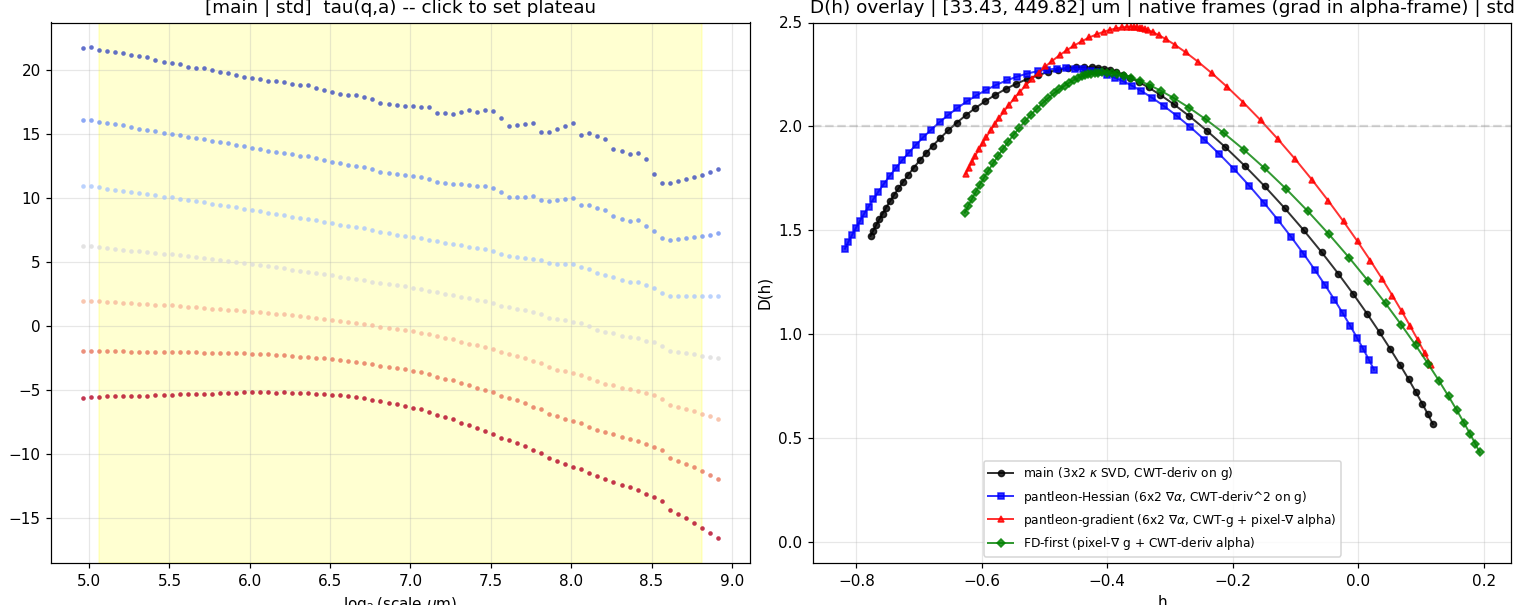

In [17]:
# ===== Interactive D(h) overlay with click-to-set plateau =====
# LEFT panel: log2 tau(q,a) for one of the three pipelines (dropdown selects).
#             LEFT-click sets plateau_min; RIGHT-click sets plateau_max.
#             Shared plateau across all three pipelines.
# RIGHT panel: D(h) overlay.  Toggle "+1 shift on grad" to bring all three
#              into the common g-frame.

%matplotlib widget
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import Dropdown, ToggleButtons, Checkbox, HBox, VBox

_pipeline_data = {
    'main':    {'std': hd_main_std,    'cmax': hd_main_cmax,    'color': 'black',    'marker': 'o'},
    'hess':    {'std': hd_hess_std,    'cmax': hd_hess_cmax,    'color': 'blue',     'marker': 's'},
    'grad':    {'std': hd_grad_std,    'cmax': hd_grad_cmax,    'color': 'red',      'marker': '^'},
    'fdfirst': {'std': hd_fdfirst_std, 'cmax': hd_fdfirst_cmax, 'color': 'green',    'marker': 'D'},
}

_pipeline_labels = {
    'main':    'main (3x2 $\\kappa$ SVD, CWT-deriv on g)',
    'hess':    'pantleon-Hessian (6x2 $\\nabla\\alpha$, CWT-deriv^2 on g)',
    'grad':    'pantleon-gradient (6x2 $\\nabla\\alpha$, CWT-g + pixel-$\\nabla$ alpha)',
    'fdfirst': 'FD-first (pixel-$\\nabla$ g + CWT-deriv alpha)',

}
# Frame-shift: g-frame pipelines have shift 0.  With UNIFY_G_FRAME=True, grad/fdfirst
# already report in g-frame (no further shift needed).  With False, shift by +1.
if UNIFY_G_FRAME:
    _pipeline_frame_shift = {'main': 0, 'hess': 0, 'grad': 0,  'fdfirst': 0,  'follow': 0, 'nmsg1': 0}
else:
    _pipeline_frame_shift = {'main': 0, 'hess': 0, 'grad': +1, 'fdfirst': +1, 'follow': 0, 'nmsg1': 0}
# follow-g1 is scalar WTMM on a single g component, in g-frame -> shift 0

_plat_state = {
    'fit_min': float(scales_um[2]  if len(scales_um) > 2 else scales_um[0]),
    'fit_max': float(scales_um[-3] if len(scales_um) > 3 else scales_um[-1]),
}

pipeline_dd = Dropdown(options=list(_pipeline_data.keys()), value='main',
                       description='tau(q,a):')
cmax_tog    = ToggleButtons(options=['Standard', 'Chainmax'], value='Standard',
                            description='PF:')
shift_cb    = Checkbox(value=(not UNIFY_G_FRAME), description='Shift alpha-pipelines by +1 (-> g-frame)')
residual_cb = Checkbox(value=True, description='Print residuals')

_fig, _axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=110)
_fig.tight_layout()

def _click(event):
    if event.inaxes is not _axes[0] or event.xdata is None: return
    a_um = 2.0 ** event.xdata
    if event.button == 1:   _plat_state['fit_min'] = a_um
    elif event.button == 3: _plat_state['fit_max'] = a_um
    if _plat_state['fit_min'] > _plat_state['fit_max']:
        _plat_state['fit_min'], _plat_state['fit_max'] = _plat_state['fit_max'], _plat_state['fit_min']
    _redraw()
_fig.canvas.mpl_connect('button_press_event', _click)

_Q_SHOW = np.array([-2, -1, 0, 1, 2, 3, 4])

def _redraw(*_):
    use_cmax = ('Chainmax' in cmax_tog.value)
    key_mode = 'cmax' if use_cmax else 'std'
    fmin, fmax = _plat_state['fit_min'], _plat_state['fit_max']

    _axes[0].cla()
    pd = _pipeline_data[pipeline_dd.value]
    hd = pd[key_mode]
    cmap = plt.cm.coolwarm(np.linspace(0, 1, len(_Q_SHOW)))
    for qv, color in zip(_Q_SHOW, cmap):
        qi = int(np.argmin(np.abs(hd['q_list'] - qv)))
        y = hd['tau_qa'][qi]; v = np.isfinite(y)
        if v.sum() < 2: continue
        _axes[0].plot(hd['log2_scales'][v], y[v], 'o', color=color, ms=3,
                      alpha=0.8, mec='none')
    _axes[0].axvspan(np.log2(fmin), np.log2(fmax), color='yellow', alpha=0.18, zorder=0)
    _axes[0].set(xlabel=r'$\log_2$(scale $\mu$m)', ylabel=r'$\log_2 Z(q,a)$',
                 title=f'[{pipeline_dd.value} | {key_mode}]  tau(q,a) -- click to set plateau')
    _axes[0].grid(True, alpha=0.3)

    _axes[1].cla()
    h_dict = {}; D_dict = {}
    for pname, pd in _pipeline_data.items():
        hd_p = pd[key_mode]
        h_raw, D_raw = _extract_Dh_from_plateau(hd_p, (fmin, fmax))
        if h_raw is None: continue
        sh = _pipeline_frame_shift.get(pname, 0) if shift_cb.value else 0
        h_plot = h_raw + sh
        valid = np.isfinite(h_plot) & np.isfinite(D_raw)
        h_dict[pname] = h_plot; D_dict[pname] = D_raw
        if valid.any():
            lbl = _pipeline_labels.get(pname, pname)
            if sh != 0 and shift_cb.value: lbl += f'  (+{sh} shift)'
            _axes[1].plot(h_plot[valid], D_raw[valid],
                          color=pd['color'], marker=pd['marker'], ms=4, lw=1.3,
                          alpha=0.8, label=lbl)
    _axes[1].axhline(2, color='gray', ls='--', alpha=0.3)
    frame_note = 'common g-frame (grad shifted)' if shift_cb.value else 'native frames (grad in alpha-frame)'
    _axes[1].set(xlabel='h', ylabel='D(h)', ylim=(-0.1, 2.5),
                 title=f'D(h) overlay | [{fmin:.2f}, {fmax:.2f}] um | {frame_note} | {key_mode}')
    _axes[1].grid(True, alpha=0.3)
    _axes[1].legend(fontsize=8, loc='lower center')
    _fig.canvas.draw_idle()

    if residual_cb.value and len(h_dict) >= 2:
        h_eval = np.linspace(-0.5, 1.8, 25)
        def _interp(pname):
            if pname not in h_dict: return None
            h_p, D_p = h_dict[pname], D_dict[pname]
            v = np.isfinite(h_p) & np.isfinite(D_p)
            if v.sum() < 3: return None
            order = np.argsort(h_p[v])
            return np.interp(h_eval, h_p[v][order], D_p[v][order],
                             left=np.nan, right=np.nan)
        Dm = _interp('main'); Dh = _interp('hess'); Dg = _interp('grad')
        msgs = []
        if Dm is not None and Dh is not None:
            msgs.append(f'mean |D_main - D_hess|          : {np.nanmean(np.abs(Dm - Dh)):.4f}')
        if Dm is not None and Dg is not None:
            msgs.append(f'mean |D_main - D_grad(shifted)| : {np.nanmean(np.abs(Dm - Dg)):.4f}')
        if Dh is not None and Dg is not None:
            msgs.append(f'mean |D_hess - D_grad(shifted)| : {np.nanmean(np.abs(Dh - Dg)):.4f}')
        if msgs:
            print(f'residuals @ plateau [{fmin:.2f}, {fmax:.2f}] um  ({key_mode}):')
            for m in msgs: print(' ', m)
            print()

pipeline_dd.observe(_redraw, names='value')
cmax_tog.observe(_redraw,   names='value')
shift_cb.observe(_redraw,   names='value')
residual_cb.observe(_redraw, names='value')

display(VBox([
    HBox([pipeline_dd, cmax_tog]),
    HBox([shift_cb, residual_cb]),
]))
print('LEFT-click tau(q,a) panel = plateau_min. RIGHT-click = plateau_max.')
print('Toggle Chainmax for running-max modulus (MBA chainmax method).')
print('Toggle "Shift grad by +1" to put grad into common g-frame.')
_redraw()


In [ ]:
a